In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload the CSV file
from google.colab import files
uploaded = files.upload()

# Load the dataset
df = pd.read_csv("StudentsPerformance.csv")

# Basic information
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

Saving StudentsPerformance.csv to StudentsPerformance.csv
First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999

In [2]:
# Task 2: Descriptive Statistics

# Mean, Median, Mode, Std, Min, Max
scores = ['math score', 'reading score', 'writing score']

for col in scores:
    print(f"\n--- {col.upper()} ---")
    print(f"Mean:   {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Mode:   {df[col].mode()[0]}")
    print(f"Std:    {df[col].std():.2f}")
    print(f"Min:    {df[col].min()}")
    print(f"Max:    {df[col].max()}")

# GroupBy gender
print("\n--- Average Scores by Gender ---")
print(df.groupby('gender')[scores].mean())

# GroupBy parental education
print("\n--- Average Scores by Parental Education ---")
print(df.groupby('parental level of education')[scores].mean())


--- MATH SCORE ---
Mean:   66.09
Median: 66.00
Mode:   65
Std:    15.16
Min:    0
Max:    100

--- READING SCORE ---
Mean:   69.17
Median: 70.00
Mode:   72
Std:    14.60
Min:    17
Max:    100

--- WRITING SCORE ---
Mean:   68.05
Median: 69.00
Mode:   74
Std:    15.20
Min:    10
Max:    100

--- Average Scores by Gender ---
        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203

--- Average Scores by Parental Education ---
                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some colleg

In [3]:
import pandas as pd
import numpy as np

# Create messy version of the dataset
messy_df = df.copy()

# Add missing values
messy_df.loc[5:15, 'math score'] = np.nan
messy_df.loc[20:25, 'reading score'] = np.nan
messy_df.loc[30:35, 'writing score'] = np.nan

# Add duplicates
messy_df = pd.concat([messy_df, messy_df.iloc[0:10]], ignore_index=True)

# Add outliers
messy_df.loc[0, 'math score'] = 200
messy_df.loc[1, 'math score'] = -50

# Save messy file
messy_df.to_csv('messy_students.csv', index=False)
print("Messy dataset created!")
print(messy_df.info())
print("\nMissing values:")
print(messy_df.isnull().sum())
print("\nDuplicates:", messy_df.duplicated().sum())

Messy dataset created!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1010 non-null   object 
 1   race/ethnicity               1010 non-null   object 
 2   parental level of education  1010 non-null   object 
 3   lunch                        1010 non-null   object 
 4   test preparation course      1010 non-null   object 
 5   math score                   994 non-null    float64
 6   reading score                1004 non-null   float64
 7   writing score                1004 non-null   float64
dtypes: float64(3), object(5)
memory usage: 63.3+ KB
None

Missing values:
gender                          0
race/ethnicity                  0
parental level of education     0
lunch                           0
test preparation course         0
math score                     16
reading scor

In [5]:
# Task 3: Data Cleaning

# Load messy dataset
clean_df = messy_df.copy()

# Step 1: Show problems
print("=== BEFORE CLEANING ===")
print(f"Shape: {clean_df.shape}")
print(f"Missing values:\n{clean_df.isnull().sum()}")
print(f"Duplicates: {clean_df.duplicated().sum()}")
print(f"\nOutliers in math score:")
print(clean_df[clean_df['math score'] > 100])
print(clean_df[clean_df['math score'] < 0])

# Step 2: Remove outliers
clean_df = clean_df[(clean_df['math score'] >= 0) & (clean_df['math score'] <= 100)]
print("\n Outliers removed")

# Step 3: Fill missing values with median
clean_df['math score'].fillna(clean_df['math score'].median(), inplace=True)
clean_df['reading score'].fillna(clean_df['reading score'].median(), inplace=True)
clean_df['writing score'].fillna(clean_df['writing score'].median(), inplace=True)
print(" Missing values filled with median")

# Step 4: Remove duplicates
clean_df.drop_duplicates(inplace=True)
print(" Duplicates removed")

# Step 5: Save cleaned file
clean_df.to_csv('cleaned_students.csv', index=False)

# Before vs After
print("\n=== AFTER CLEANING ===")
print(f"Shape: {clean_df.shape}")
print(f"Missing values:\n{clean_df.isnull().sum()}")
print(f"Duplicates: {clean_df.duplicated().sum()}")
print("\nCleaned data summary:")
print(clean_df.describe())

=== BEFORE CLEANING ===
Shape: (1010, 8)
Missing values:
gender                          0
race/ethnicity                  0
parental level of education     0
lunch                           0
test preparation course         0
math score                     16
reading score                   6
writing score                   6
dtype: int64
Duplicates: 8

Outliers in math score:
   gender race/ethnicity parental level of education     lunch  \
0  female        group B           bachelor's degree  standard   

  test preparation course  math score  reading score  writing score  
0                    none       200.0           72.0           74.0  
   gender race/ethnicity parental level of education     lunch  \
1  female        group C                some college  standard   

  test preparation course  math score  reading score  writing score  
1               completed       -50.0           90.0           88.0  

 Outliers removed
 Missing values filled with median
 Duplicates removed

/tmp/ipykernel_401/2993233513.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df['math score'].fillna(clean_df['math score'].median(), inplace=True)
/tmp/ipykernel_401/2993233513.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

--- By Gender ---
        math score  reading score  writing score
gender                                          
female   63.634766      72.570312      72.492188
male     68.861635      65.587002      63.423480

--- By Race/Ethnicity ---
                math score  reading score  writing score
race/ethnicity                                          
group A          61.574713      64.678161      62.643678
group B          63.535135      67.189189      65.621622
group C          64.470032      69.123028      67.845426
group D          67.480769      70.184615      70.361538
group E          73.821429      73.028571      71.271429

--- By Parental Education ---
                             math score  reading score  writing score
parental level of education                                          
associate's degree            68.041096      71.036530      70.018265
bachelor's degree             69.389831      72.991525      73.381356
high school                   62.238342      64.6

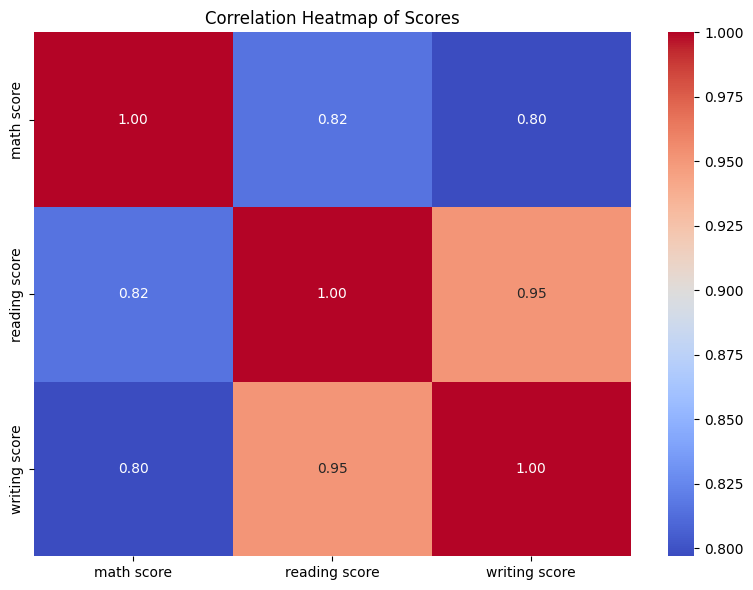

Heatmap saved!


In [6]:
# Task 4: EDA & Correlation

scores = ['math score', 'reading score', 'writing score']

# GroupBy analysis
print("--- By Gender ---")
print(clean_df.groupby('gender')[scores].mean())

print("\n--- By Race/Ethnicity ---")
print(clean_df.groupby('race/ethnicity')[scores].mean())

print("\n--- By Parental Education ---")
print(clean_df.groupby('parental level of education')[scores].mean())

print("\n--- By Test Preparation Course ---")
print(clean_df.groupby('test preparation course')[scores].mean())

# Correlation Matrix
print("\n--- Correlation Matrix ---")
print(clean_df[scores].corr())

# Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(clean_df[scores].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Scores')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()
print("Heatmap saved!")

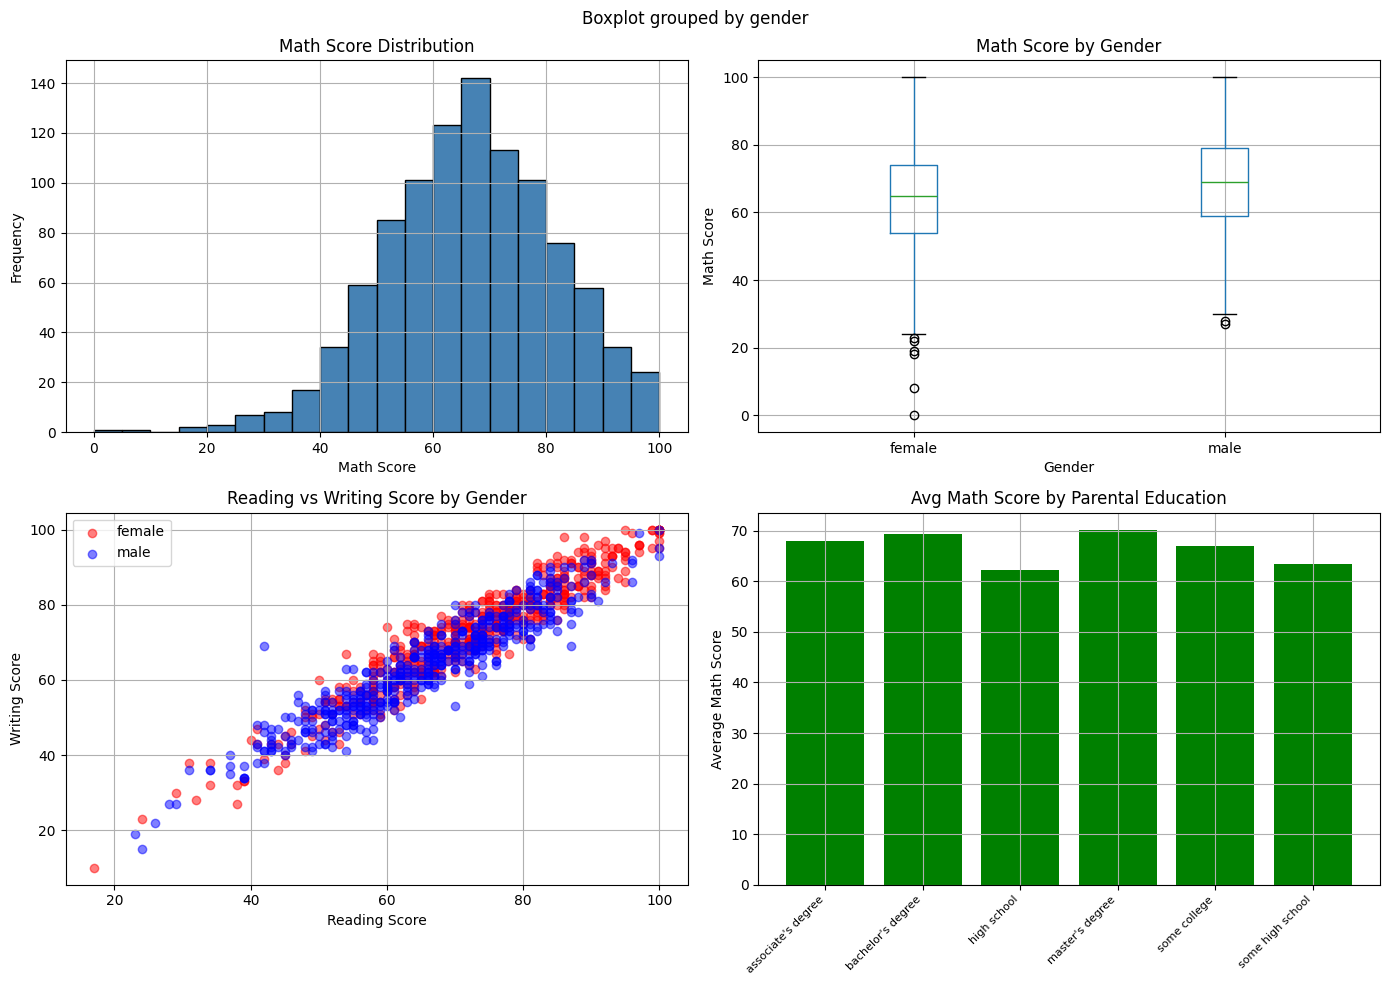

Saved!


In [7]:
# Task 5: Data Visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Student Performance Analysis', fontsize=16)

# 1. Histogram with KDE
axes[0,0].hist(clean_df['math score'], bins=20, color='steelblue', edgecolor='black')
axes[0,0].set_title('Math Score Distribution')
axes[0,0].set_xlabel('Math Score')
axes[0,0].set_ylabel('Frequency')
axes[0,0].grid(True)

# 2. Boxplot by gender
clean_df.boxplot(column='math score', by='gender', ax=axes[0,1])
axes[0,1].set_title('Math Score by Gender')
axes[0,1].set_xlabel('Gender')
axes[0,1].set_ylabel('Math Score')
axes[0,1].grid(True)

# 3. Scatter plot
colors = {'male':'blue', 'female':'red'}
for gender, group in clean_df.groupby('gender'):
    axes[1,0].scatter(group['reading score'], group['writing score'],
                      label=gender, alpha=0.5, color=colors[gender])
axes[1,0].set_title('Reading vs Writing Score by Gender')
axes[1,0].set_xlabel('Reading Score')
axes[1,0].set_ylabel('Writing Score')
axes[1,0].legend()
axes[1,0].grid(True)

# 4. Bar chart
edu_means = clean_df.groupby('parental level of education')['math score'].mean()
axes[1,1].bar(range(len(edu_means)), edu_means.values, color='green')
axes[1,1].set_xticks(range(len(edu_means)))
axes[1,1].set_xticklabels(edu_means.index, rotation=45, ha='right', fontsize=8)
axes[1,1].set_title('Avg Math Score by Parental Education')
axes[1,1].set_ylabel('Average Math Score')
axes[1,1].grid(True)

plt.tight_layout()
plt.savefig('best_visualization.png')
plt.show()
print("Saved!")